# Data Science Programming
## Web Scraping and Domain Analysis (OpenFoodFacts)

### Problem Definition
Scrape real-world data (minimum 1000 rows), preprocess it with Python, then analyze and visualize at least 5 questions.

### Data Source
- Website: https://world.openfoodfacts.org/
- Domain: Food products and nutrition labels
- Scraping endpoint (JSON search): https://world.openfoodfacts.org/cgi/search.pl

### Methodology (Summary)
1. Collect product data from the OpenFoodFacts search endpoint (multiple pages).
2. Clean numeric nutrition fields and remove duplicates.
3. Analyze and visualize patterns across categories, brands, and nutrition grades.
4. Summarize insights.

### Questions (6)
1. How many products were scraped and how many unique brands exist?
2. What are the top 10 product categories by count?
3. What is the distribution of nutrition grades?
4. How do sugar levels vary by nutrition grade?
5. Which countries appear most frequently?
6. Is there a correlation between sugar and calories?

### Import Libraries

In [1]:
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

### Scraping Configuration

In [5]:
BASE_URL = "https://world.openfoodfacts.org/cgi/search.pl"
OUTPUT_PATH = Path("data/openfoodfacts_products.csv")

FIELDS = [
    "product_name",
    "brands",
    "categories",
    "countries",
    "nutrition_grades",
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "sugars_100g",
    "salt_100g",
    "proteins_100g",
    "fiber_100g",
]

PAGES = 20
PAGE_SIZE = 150
MIN_ROWS = 1000

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36",
}

### Scrape Products (1000+ Rows)

In [6]:
records = []

session = requests.Session()

if OUTPUT_PATH.exists():
    df = pd.read_csv(OUTPUT_PATH)
else:
    df = pd.DataFrame()

if len(df) < MIN_ROWS:
    records = []
    for page in range(1, PAGES + 1):
        params = {
            "search_simple": 1,
            "action": "process",
            "page": page,
            "page_size": PAGE_SIZE,
            "json": 1,
            "fields": ",".join(FIELDS),
        }

        for attempt in range(1, 4):
            try:
                response = session.get(BASE_URL, headers=HEADERS, params=params, timeout=30)
                response.raise_for_status()
                payload = response.json()
                products = payload.get("products", [])
                records.extend(products)
                break
            except requests.HTTPError as exc:
                if attempt == 3:
                    print(f"Page {page} failed after retries: {exc}")
                else:
                    time.sleep(1.5 * attempt)
            except requests.RequestException as exc:
                if attempt == 3:
                    print(f"Page {page} failed after retries: {exc}")
                else:
                    time.sleep(1.5 * attempt)

        time.sleep(0.3)

    if len(records) < MIN_ROWS:
        for page in range(PAGES + 1, PAGES + 11):
            params = {
                "search_simple": 1,
                "action": "process",
                "page": page,
                "page_size": PAGE_SIZE,
                "json": 1,
                "fields": ",".join(FIELDS),
            }
            for attempt in range(1, 4):
                try:
                    response = session.get(BASE_URL, headers=HEADERS, params=params, timeout=30)
                    response.raise_for_status()
                    payload = response.json()
                    products = payload.get("products", [])
                    records.extend(products)
                    break
                except requests.HTTPError as exc:
                    if attempt == 3:
                        print(f"Extra page {page} failed after retries: {exc}")
                    else:
                        time.sleep(1.5 * attempt)
                except requests.RequestException as exc:
                    if attempt == 3:
                        print(f"Extra page {page} failed after retries: {exc}")
                    else:
                        time.sleep(1.5 * attempt)
            time.sleep(0.3)

    df = pd.DataFrame(records)
    df.to_csv(OUTPUT_PATH, index=False)

df.shape

Page 5 failed after retries: 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?search_simple=1&action=process&page=5&page_size=150&json=1&fields=product_name%2Cbrands%2Ccategories%2Ccountries%2Cnutrition_grades%2Cenergy-kcal_100g%2Cfat_100g%2Csaturated-fat_100g%2Csugars_100g%2Csalt_100g%2Cproteins_100g%2Cfiber_100g
Page 6 failed after retries: 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?search_simple=1&action=process&page=6&page_size=150&json=1&fields=product_name%2Cbrands%2Ccategories%2Ccountries%2Cnutrition_grades%2Cenergy-kcal_100g%2Cfat_100g%2Csaturated-fat_100g%2Csugars_100g%2Csalt_100g%2Cproteins_100g%2Cfiber_100g
Page 7 failed after retries: 503 Server Error: Service Temporarily Unavailable for url: https://world.openfoodfacts.org/cgi/search.pl?search_simple=1&action=process&page=7&page_size=150&json=1&fields=product_name%2Cbrands%2Ccategories%2Ccountries%2Cnutriti

(1187, 19)

### Raw Data Preview

In [7]:
df.head(5)

,brands,categories,countries,energy-kcal_100g,fat_100g,nutrition_data,nutrition_data_prepared_per,nutrition_grades,product_name,proteins_100g,fiber_100g,nutrition_data_per,salt_100g,saturated-fat_100g,sugars_100g,nutriments_estimated,serving_quantity,nutrition_data_prepared,no_nutrition_data
0,Milky Food Professional,"Produits laitiers,Produits fermentés,Produits ...","Canada,France,Maroc,États-Unis",80.6,12.0,on,100g,unknown,Fromage Blanc Nature,7.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,سيدي علي,"Beverages and beverages preparations,Beverages...","Canada, France, Morocco, United States, en:uni...",0.0,0.0,on,100g,a,Sidi Ali,0.0,0.0,100g,0.000,0.0,1.4,NaN,NaN,NaN,NaN
2,Jaouda,"Produits laitiers,Produits fermentés,Produits ...","France, India, Morocco, United States, en:neth...",97.0,3.0,on,100g,a,Perly,8.0,0.0,NaN,0.000,0.0,9.4,NaN,NaN,NaN,NaN
3,sidi ali,"Bevande e preparati per bevande,Bevande,Acque,...","Canada,Francia,Germania,Marocco,Paesi Bassi,Re...",0.0,0.0,on,100g,a,Eau minérale naturelle,0.0,NaN,NaN,0.006,NaN,NaN,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,NaN
4,Sidi Ali,"Beverages and beverages preparations,Beverages...","France, Morocco, United States, en:canada",NaN,NaN,on,100g,a,Sidi Ali,NaN,NaN,100ml,0.065,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.tail(5)

,brands,categories,countries,energy-kcal_100g,fat_100g,nutrition_data,nutrition_data_prepared_per,nutrition_grades,product_name,proteins_100g,fiber_100g,nutrition_data_per,salt_100g,saturated-fat_100g,sugars_100g,nutriments_estimated,serving_quantity,nutrition_data_prepared,no_nutrition_data
1182,Le Guérandais,"Condiments, Sels, Sels français, Sels marins, ...",France,0.0,0.0,on,100g,not-applicable,Sel moulu de Guérande,0.0,0.0,100g,85.0,0.00,0.00,"{'alcohol_100g': 0, 'beta-carotene_100g': 0, '...",NaN,NaN,NaN
1183,Capri-Sun,"plant-based-foods-and-beverages, beverages, pl...","Belgium, France, Spain, Switzerland, en:portugal",31.0,0.0,on,100g,d,Multivitamin Capri-Sun,0.0,0.0,100ml,0.0,0.00,7.30,NaN,NaN,NaN,NaN
1184,Kellogg's,"Aliments et boissons à base de végétaux,Alimen...","France,Mexique",375.0,1.5,on,100g,c,Céréales Special K Kellogg's Nature,9.0,4.5,100g,1.0,0.30,15.00,NaN,NaN,NaN,NaN
1185,Chergui,"Produits laitiers, Produits fermentés, Dessert...",Morocco,102.0,0.1,on,100g,unknown,Yaourt Jnane,10.0,NaN,100g,NaN,0.01,13.68,NaN,NaN,NaN,NaN
1186,KNORR,"Aliments et boissons à base de végétaux,Alimen...",France,NaN,NaN,NaN,100g,c,"Soupe Thai (Nouilles, champignons et pousses ...",NaN,NaN,100g,NaN,NaN,NaN,NaN,NaN,on,NaN


### Cleaning

In [10]:
dedupe_cols = [
    "product_name",
    "brands",
    "categories",
    "countries",
    "nutrition_grades",
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "sugars_100g",
    "salt_100g",
    "proteins_100g",
    "fiber_100g",
]

# Drop duplicates using hashable columns only
if all(col in df.columns for col in dedupe_cols):
    df = df.drop_duplicates(subset=dedupe_cols)
else:
    df = df.drop_duplicates()

df = df[df["product_name"].notna()]

numeric_cols = [
    "energy-kcal_100g",
    "fat_100g",
    "saturated-fat_100g",
    "sugars_100g",
    "salt_100g",
    "proteins_100g",
    "fiber_100g",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["brand_primary"] = df["brands"].fillna("Unknown").str.split(",").str[0].str.strip()
df["category_primary"] = df["categories"].fillna("Unknown").str.split(",").str[0].str.strip()
df["country_primary"] = df["countries"].fillna("Unknown").str.split(",").str[0].str.strip()
df["nutrition_grade"] = df["nutrition_grades"].str.upper().fillna("Unknown")

df.shape

(1162, 23)

### Q1. How many products were scraped and how many unique brands exist?

In [11]:
product_count = len(df)
brand_count = df["brand_primary"].nunique()
product_count, brand_count

(1162, 531)

### Q2. What are the top 10 product categories by count?

In [12]:
top_categories = df["category_primary"].value_counts().head(10)
top_categories

category_primary
Aliments et boissons à base de végétaux    210
Snacks                                     191
Plant-based foods and beverages            124
Produits laitiers                           91
Dairies                                     50
Condiments                                  44
Boissons et préparations de boissons        41
Beverages and beverages preparations        37
Boissons                                    24
Alimentos y bebidas de origen vegetal       20
Name: count, dtype: int64

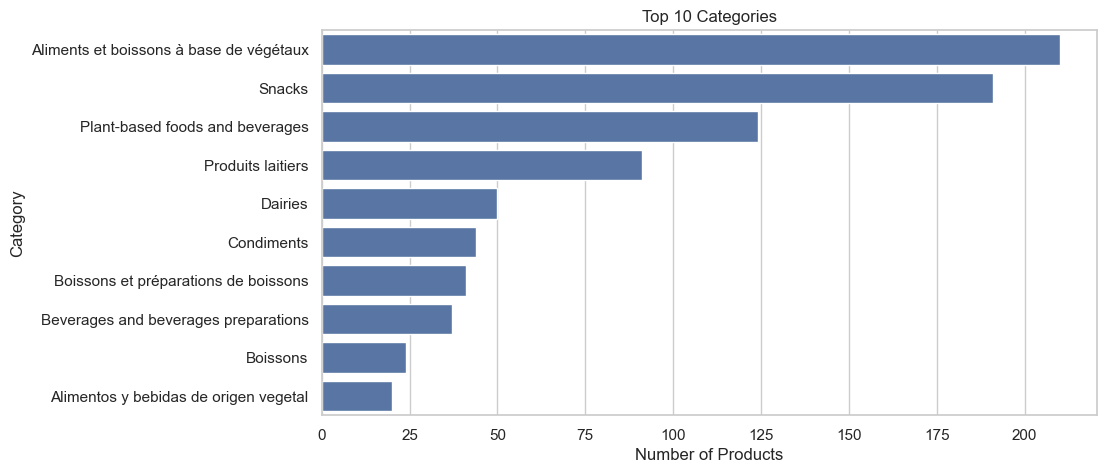

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top 10 Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.show()

### Q3. What is the distribution of nutrition grades?

In [14]:
grade_counts = df["nutrition_grade"].value_counts()
grade_counts

nutrition_grade
C                 264
E                 230
D                 211
A                 196
B                 168
UNKNOWN            64
NOT-APPLICABLE     29
Name: count, dtype: int64

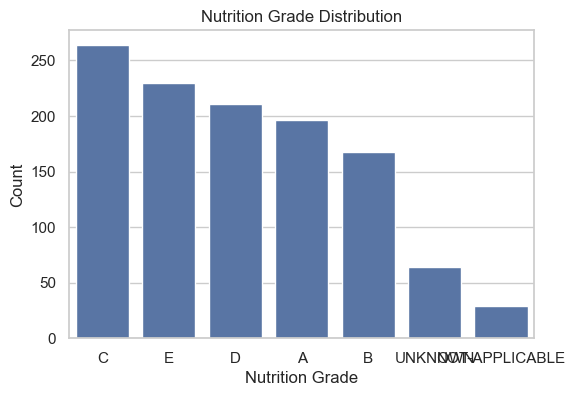

In [15]:
plt.figure(figsize=(6, 4))
sns.barplot(x=grade_counts.index, y=grade_counts.values)
plt.title("Nutrition Grade Distribution")
plt.xlabel("Nutrition Grade")
plt.ylabel("Count")
plt.show()

### Q4. How do sugar levels vary by nutrition grade?

In [16]:
sugar_by_grade = df.groupby("nutrition_grade")["sugars_100g"].median().sort_index()
sugar_by_grade

nutrition_grade
A                  2.550
B                  2.450
C                  4.315
D                  6.000
E                 27.000
NOT-APPLICABLE     2.150
UNKNOWN            2.980
Name: sugars_100g, dtype: float64

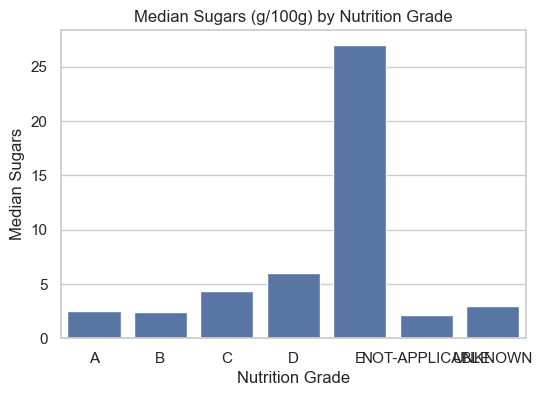

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(x=sugar_by_grade.index, y=sugar_by_grade.values)
plt.title("Median Sugars (g/100g) by Nutrition Grade")
plt.xlabel("Nutrition Grade")
plt.ylabel("Median Sugars")
plt.show()

### Q5. Which countries appear most frequently?

In [18]:
top_countries = df["country_primary"].value_counts().head(10)
top_countries

country_primary
France        573
Belgium       113
Morocco        96
Belgique       53
en:Morocco     32
Maroc          29
Austria        21
en:ma          19
en:fr          17
Algeria        15
Name: count, dtype: int64

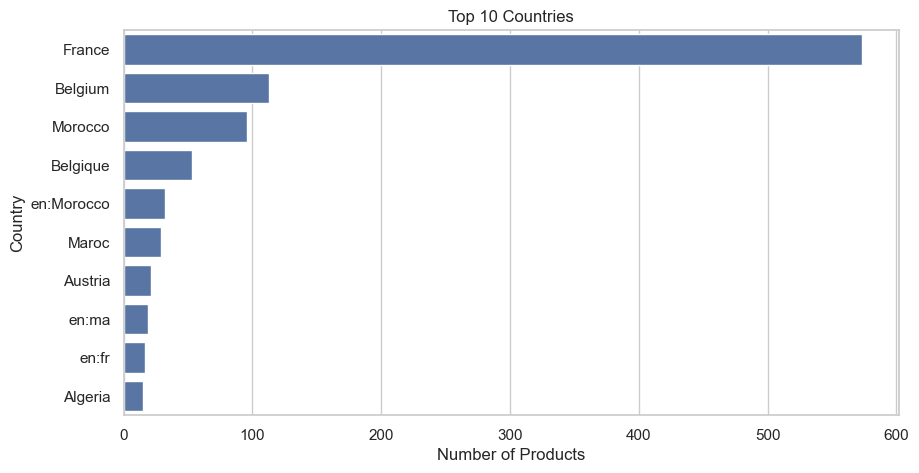

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries")
plt.xlabel("Number of Products")
plt.ylabel("Country")
plt.show()

### Q6. Is there a correlation between sugar and calories?

In [20]:
subset = df.dropna(subset=["sugars_100g", "energy-kcal_100g"]).copy()
subset = subset[(subset["sugars_100g"] >= 0) & (subset["energy-kcal_100g"] >= 0)]
corr = subset[["sugars_100g", "energy-kcal_100g"]].corr().iloc[0, 1]
corr

np.float64(0.2427999703893036)

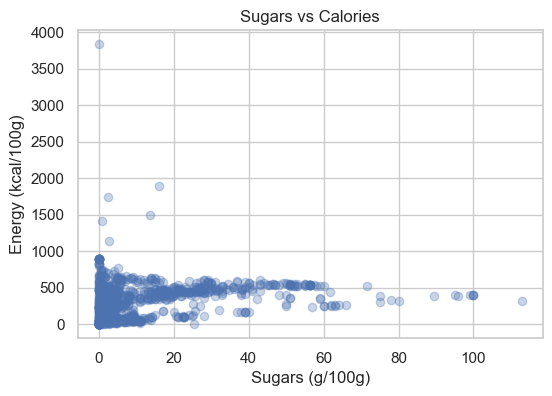

In [21]:
plot_sample = subset.sample(3000, random_state=42) if len(subset) > 3000 else subset
plt.figure(figsize=(6, 4))
plt.scatter(plot_sample["sugars_100g"], plot_sample["energy-kcal_100g"], alpha=0.3)
plt.title("Sugars vs Calories")
plt.xlabel("Sugars (g/100g)")
plt.ylabel("Energy (kcal/100g)")
plt.show()

### References
- Website: https://world.openfoodfacts.org/
- Scraping endpoint: https://world.openfoodfacts.org/cgi/search.pl
- Tools: Python, Requests, Pandas, NumPy, Seaborn, Matplotlib